# Taller 4: Detección de contornos

## Cargue y visualice la imagen spot.png.

In [1]:
PATH = "./imagenes/"

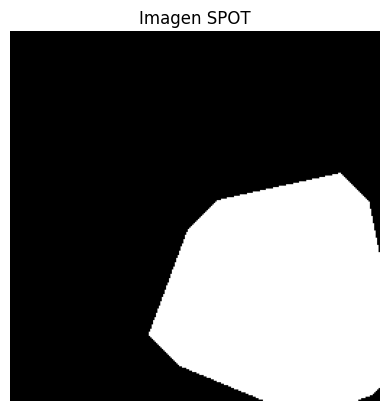

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen_spot = cv2.imread(PATH + "SPOT.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(imagen_spot, cmap='gray')
plt.title('Imagen SPOT')
plt.axis('off')
plt.show()

## Antes de aplicar el filtro Laplaciano es necesario modificar el tipo de la imagen para que esta pueda contener niveles de gris negativos. Convierta la imagen a tipo Int16.

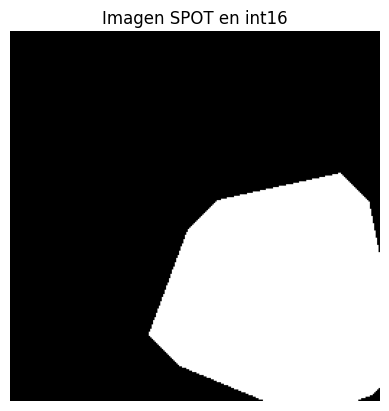

In [4]:
imagen_spot_int16 = imagen_spot.astype(np.int16)
plt.imshow(imagen_spot_int16, cmap='gray')
plt.title('Imagen SPOT en int16')
plt.axis('off')
plt.show()

## Aplique un filtro Laplaciano. Visualice el resultado ****(puede efectuar una calibración del histograma -entre 0 y 255- de la imagen obtenida para visualizar mejor los detalles de la imagen del Laplaciano).

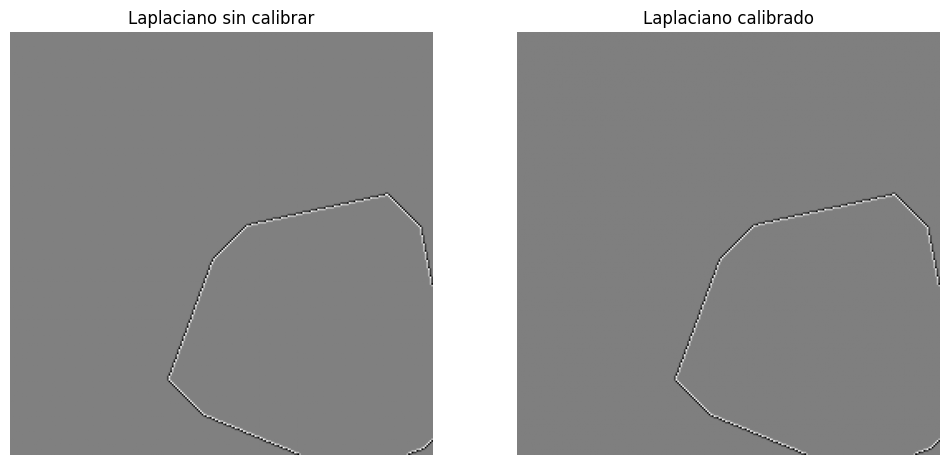

In [6]:
from skimage.filters import laplace
from skimage import exposure

img_laplace = laplace(imagen_spot_int16, ksize=3)
img_laplace_calibrada = exposure.rescale_intensity(img_laplace, in_range=(img_laplace.min(), img_laplace.max()),\
                                               out_range=(0, 255)).astype(np.uint8)
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img_laplace, cmap='gray')
ax[0].set_title('Laplaciano sin calibrar')
ax[0].axis('off')
ax[1].imshow(img_laplace_calibrada, cmap='gray')
ax[1].set_title('Laplaciano calibrado')
ax[1].axis('off')
plt.show()

## ¿Cómo es la respuesta del Laplaciano en las regiones homogéneas de la imagen y en los contornos? ¿A qué se debe este resultado?

La respuesta del Laplaciano en las regiones homogéneas de la imagen es cercana a cero, ya que no hay variaciones de intensidad. En los contornos, el Laplaciano genera valores altos (positivos o negativos), resaltando los cambios bruscos de intensidad.
Este resultado se debe a que el Laplaciano es un operador de segundo orden que calcula la suma de las derivadas, detectando zonas donde la intensidad cambia rápidamente, es decir, los bordes.

## Aplique un filtro Gaussiano con varianza en 0 a la imagen. Visualice el resultado.

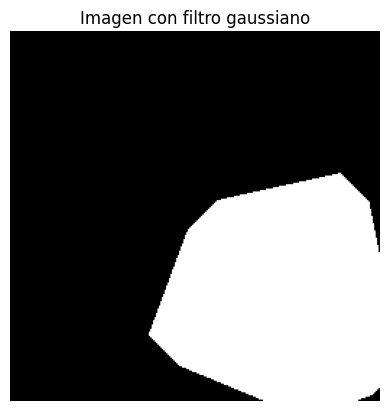

In [8]:
from skimage.filters import gaussian

img_gaussian = gaussian(imagen_spot_int16, sigma=0, preserve_range=True)
plt.imshow(img_gaussian, cmap='gray')
plt.title('Imagen con filtro gaussiano')
plt.axis('off')
plt.show()

## Aplique sobre el resutlado del paso anterior un filtro Laplaciano. Visualice el resultado ****(puede efectuar una calibración del histograma -entre 0 y 255- de la imagen obtenida para visualizar mejor los detalles de la imagen del Laplaciano). ¿Cómo es la respuesta de este LoG con respecto al Laplaciano sin filtrado previo del ejercicio anterior? ¿A qué se debe este resultado?

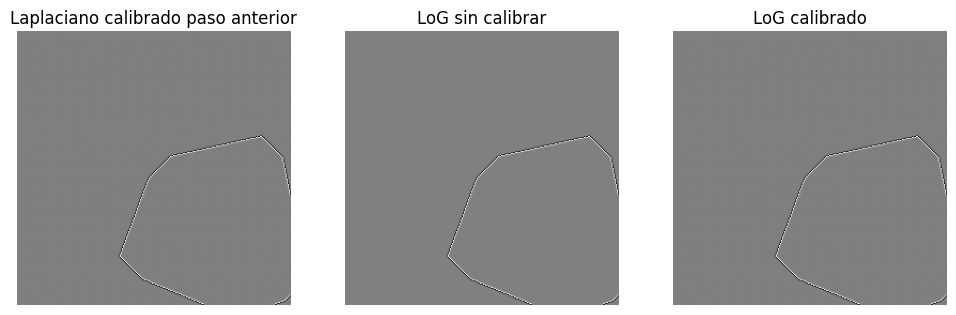

In [ ]:
from skimage.filters import laplace
from skimage import exposure

img_gaussiano_laplace = laplace(img_gaussian, ksize=3)
img_gaussiano_laplace_calibrada = exposure.rescale_intensity(img_gaussiano_laplace,\
                                            in_range=(img_gaussiano_laplace.min(),img_gaussiano_laplace.max()),\
                                            out_range=(0, 255)).astype(np.uint8)
fig, ax = plt.subplots(1, 3, figsize=(12, 6))
ax[0].imshow(img_laplace_calibrada, cmap='gray')
ax[0].set_title('Laplaciano calibrado paso anterior')
ax[0].axis('off')
ax[1].imshow(img_gaussiano_laplace, cmap='gray')
ax[1].set_title('LoG sin calibrar')
ax[1].axis('off')
ax[2].imshow(img_gaussiano_laplace_calibrada, cmap='gray')
ax[2].set_title('LoG calibrado')
ax[2].axis('off')
plt.show()

Obtenemos la misma imagen que obtuvimos en el paso anterior sin el filtro gaussiano. Esto se debe a que la imagen SPOT no tiene ruido y el valor de sigma es 0, entonces el efecto del filtro en este caso es nulo.

## Repita los pasos 1 y 2, pero cambiando a 1 el valor de la varianza en el filtro gaussiano. ¿Cómo es la respuesta de este LoG con respecto al Laplaciano sin filtrado previo del ejercicio anterior? ¿A qué se debe este resultado?

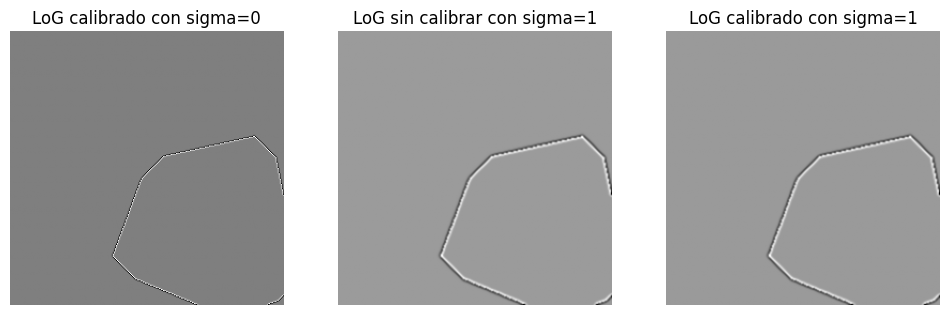

In [14]:
img_gaussian_sigma1 = gaussian(imagen_spot_int16, sigma=1, preserve_range=True)
img_gaussian_sigma1_laplace = laplace(img_gaussian_sigma1, ksize=3)
img_gaussian_sigma1_laplace_calibrada = exposure.rescale_intensity(img_gaussian_sigma1_laplace,\
                                            in_range=(img_gaussian_sigma1_laplace.min(),img_gaussian_sigma1_laplace.max()),\
                                            out_range=(0, 255)).astype(np.uint8)
fig, ax = plt.subplots(1, 3, figsize=(12, 6))
ax[0].imshow(img_gaussiano_laplace_calibrada, cmap='gray')
ax[0].set_title('LoG calibrado con sigma=0')
ax[0].axis('off')
ax[1].imshow(img_gaussian_sigma1_laplace, cmap='gray')
ax[1].set_title('LoG sin calibrar con sigma=1')
ax[1].axis('off')
ax[2].imshow(img_gaussian_sigma1_laplace_calibrada, cmap='gray')
ax[2].set_title('LoG calibrado con sigma=1')
ax[2].axis('off')
plt.show()

Al aplicar el filtro LoG con sigma=1, la respuesta es muy similar al Laplaciano sin filtrado previo, pero se observa un leve cambio en los bordes: estos aparecen ligeramente más suavizados y menos definidos.
Esto ocurre porque el filtro gaussiano con sigma=1 introduce un pequeño suavizado, que reduce mínimamente el contraste en los contornos.

## Repita los pasos 1 y 2, pero cambiando a 2 el valor de la varianza en el filtro gaussiano. ¿Cómo es la respuesta de este LoG? ¿A qué se debe este resultado?

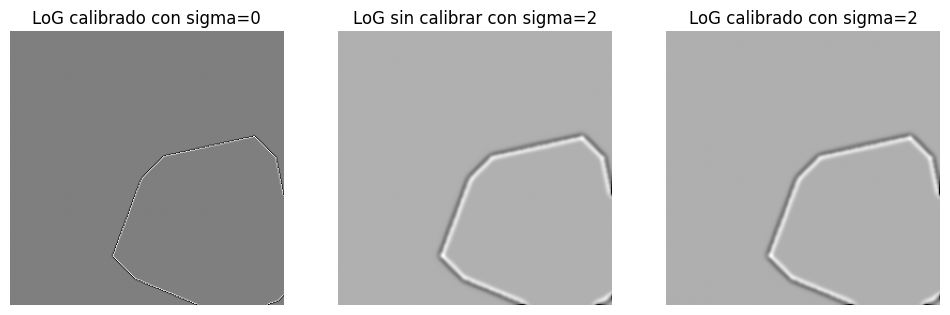

In [15]:
img_gaussian_sigma2 = gaussian(imagen_spot_int16, sigma=2, preserve_range=True)
img_gaussian_sigma2_laplace = laplace(img_gaussian_sigma2, ksize=3)
img_gaussian_sigma2_laplace_calibrada = exposure.rescale_intensity(img_gaussian_sigma2_laplace,\
                                            in_range=(img_gaussian_sigma2_laplace.min(),img_gaussian_sigma2_laplace.max()),\
                                            out_range=(0, 255)).astype(np.uint8)
fig, ax = plt.subplots(1, 3, figsize=(12, 6))
ax[0].imshow(img_gaussiano_laplace_calibrada, cmap='gray')
ax[0].set_title('LoG calibrado con sigma=0')
ax[0].axis('off')
ax[1].imshow(img_gaussian_sigma2_laplace, cmap='gray')
ax[1].set_title('LoG sin calibrar con sigma=2')
ax[1].axis('off')
ax[2].imshow(img_gaussian_sigma2_laplace_calibrada, cmap='gray')
ax[2].set_title('LoG calibrado con sigma=2')
ax[2].axis('off')
plt.show()

Al aplicar el filtro LoG con sigma=2, el suavizado es mucho más notorio. Los bordes se ven más anchos y menos definidos, y el contraste en los contornos disminuye.
Esto ocurre porque el filtro gaussiano elimina más detalles y difumina los bordes, haciendo que pierdan nitidez. Las zonas homogéneas siguen igual, pero los contornos se ven más suaves y menos marcados.

## Cargue la imagen bruit y visualícela. Aplique un filtro gaussiano (con varianza igual a 1) y un filtro Laplaciano siguiendo los mismos pasos de los ejercicios previos. Visualice la imagen del LoG.